In [1]:
import xarray 
import matplotlib.pyplot as plt

In [2]:
import cartopy.crs as ccrs
from cartopy.mpl.geoaxes import GeoAxes


def plot_2d_latlon_dataarray(
    da, ax, projection=ccrs.PlateCarree(), coastline_kwargs=None, **plot_kwargs
):
    """
    Validate and plot a 2D xarray.DataArray on the provided axes.

    Requirements enforced:
    - Input is an xarray.DataArray
    - DataArray has exactly 2 dimensions
    - Dimensions are exactly {'latitude', 'longitude'}
    """
    if not isinstance(da, xarray.DataArray):
        raise TypeError("Expected an xarray.DataArray as input.")

    if da.ndim != 2:
        raise ValueError(f"Expected a 2D DataArray, got {da.ndim}D with dims {da.dims}.")

    if set(da.dims) != {"latitude", "longitude"}:
        raise ValueError(
            "DataArray must have exactly 'latitude' and 'longitude' dimensions; "
            f"got {da.dims}."
        )

    lon = da["longitude"].values
    lat = da["latitude"].values

    if isinstance(ax, GeoAxes):
        quadmesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            transform=projection,
            **plot_kwargs,
        )
        ax.set_extent(
            [
                float(lon.min()),
                float(lon.max()),
                float(lat.min()),
                float(lat.max()),
            ],
            crs=projection,
        )

        coastline_style = {
            "resolution": "10m",
            "linewidth": 0.8,
            "color": "black",
            "zorder": 4,
        }
        if coastline_kwargs:
            coastline_style.update(coastline_kwargs)
        ax.coastlines(**coastline_style)
    else:
        quadmesh = ax.pcolormesh(da["longitude"], da["latitude"], da, **plot_kwargs)

    return quadmesh

In [3]:
from typing import Optional 

def _load_and_validate(
    path: str, chunks: Optional[str | dict] = "auto"
) -> xarray.Dataset:
    import hdf5plugin  # specifies path to look for alternative hdf5 decompression algo

    def _validate_opened_dataset(ds: xarray.Dataset) -> None | Warning:
        if ds.nbytes == 0:
            return Warning(f"Empty object: 0 bytes of data.")

        var = list(ds.data_vars)[0]
        indexers = {d: 0 for d in ds[var].dims}

        try:
            # May trigger full data read if not chunked.
            ds[var].isel(indexers).load()
        except Exception as e:
            return Warning("Failed loading data.")

    engines = ["netcdf4", "h5netcdf", "scipy"]
    for eng in engines:
        ds = xarray.open_dataset(path, engine=eng, chunks=chunks)
        if _validate_opened_dataset(ds):
            continue
        return ds

    raise ValueError(
        f"Failed to open dataset at {path} with any of the engines: {engines}"
    )

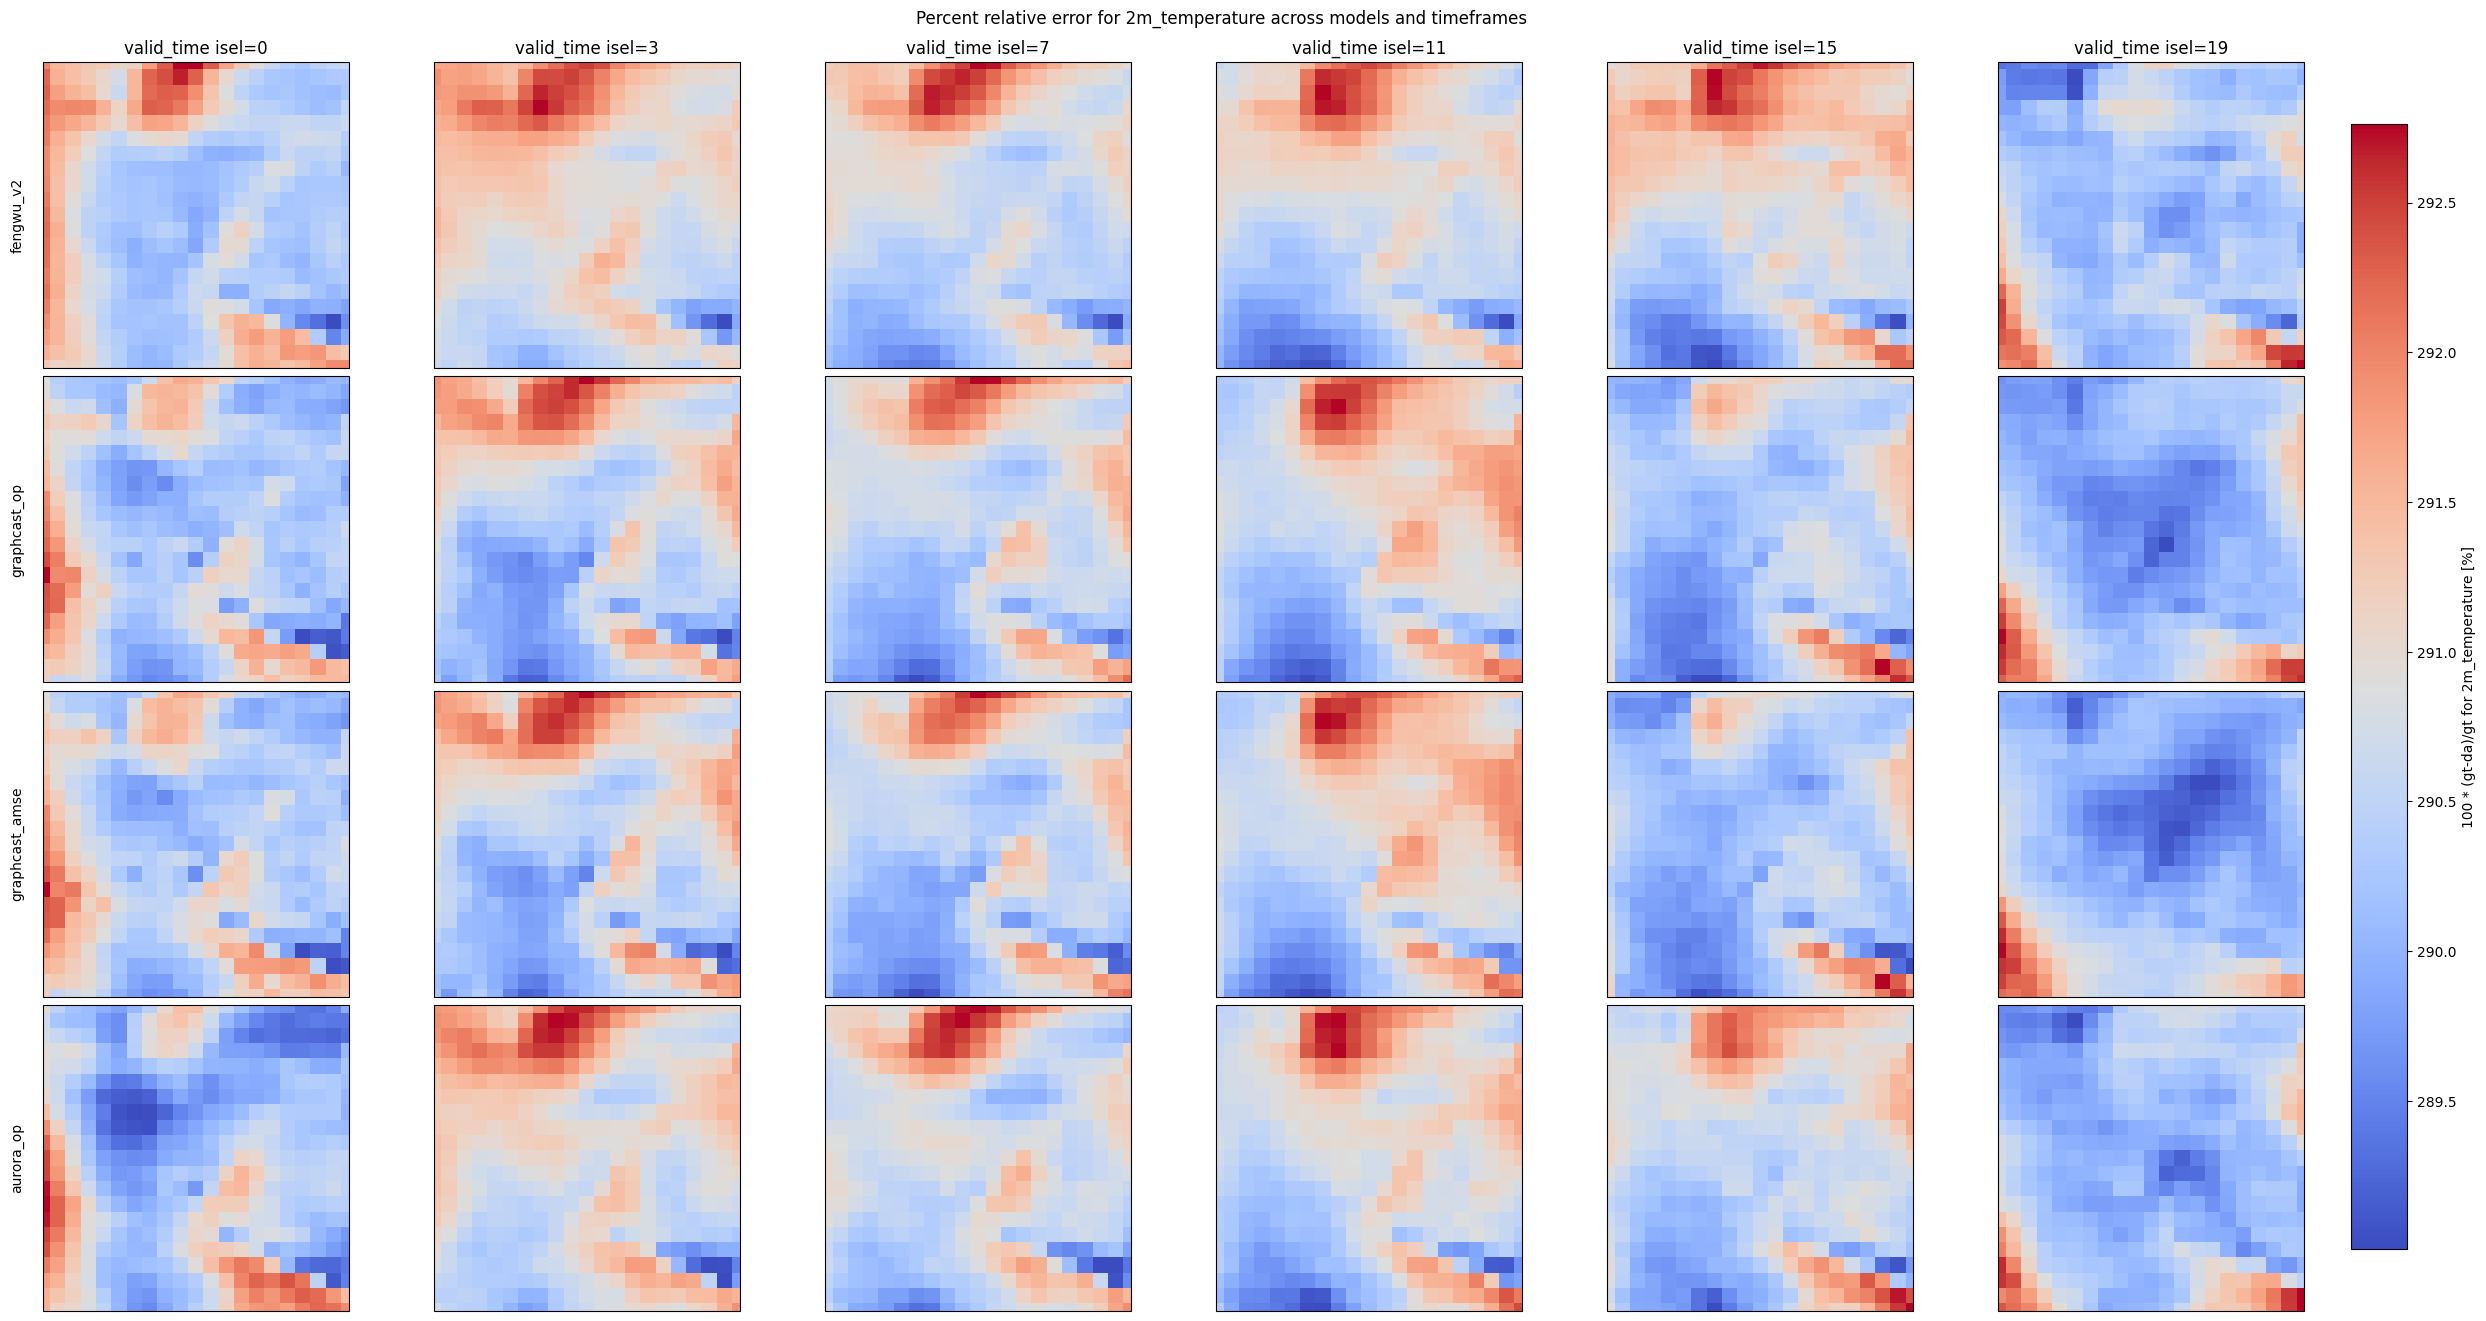

In [67]:
import numpy as np

root = "/home/users/f/froelicm/scratch/output/aiwm2_test_hres_fc0/"
runs = ["fengwu_v2.nc", "graphcast_op.nc", "graphcast_amse.nc", "aurora_op.nc"]

gt = "/home/users/f/froelicm/scratch/hresf0-fc0/weatherbench2_hres_t0_2022_01.nc"

var = "2m_temperature"
timeframes = [0, 3, 7, 11, 15, 19]  # indices for isel on the time dimension

lat_region = [25, 30]  # min and max latitude
lon_region = [25, 30]  # min and max longitude, 0-360 convention

# Open datasets once so we can reuse them while plotting
datasets = [_load_and_validate(f"{root}{run}", chunks="auto") for run in runs]

gt = _load_and_validate(gt, chunks="auto").sel(valid_time=datasets[0].valid_time.values)[var]
gt = gt.sortby("latitude").sortby("longitude")

n_rows = len(datasets)
n_cols = len(timeframes)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.2 * n_cols, 3.2 * n_rows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

# Keep axes indexing 2D even if rows/cols are 1
if n_rows == 1 and n_cols == 1:
    axes = [[axes]]
elif n_rows == 1:
    axes = [axes]
elif n_cols == 1:
    axes = [[ax] for ax in axes]

lat_min, lat_max = sorted(lat_region)
lon_start = lon_region[0] % 360
lon_end = lon_region[1] % 360

def subset_region_0_360(da2d):
    da2d = da2d.sortby("latitude").sortby("longitude")
    da2d = da2d.sel(latitude=slice(lat_min, lat_max))

    # Handle 0-360 windows, including wraparound (e.g., 350 -> 20).
    if lon_start <= lon_end:
        return da2d.sel(longitude=slice(lon_start, lon_end))

    da_west = da2d.sel(longitude=slice(lon_start, 360))
    da_east = da2d.sel(longitude=slice(0, lon_end))
    return xarray.concat([da_west, da_east], dim="longitude")

for i, (run, ds) in enumerate(zip(runs, datasets)):
    if var not in ds:
        raise KeyError(f"Variable '{var}' not found in dataset {run}.")

    da = ds[var].sortby("latitude").sortby("longitude")

    # Choose a likely time dimension for isel
    if "time" in da.dims:
        time_dim = "time"
    elif "valid_time" in da.dims:
        time_dim = "valid_time"
    elif "datetime" in da.dims:
        time_dim = "datetime"
    else:
        raise ValueError(
            f"No supported time dimension found in {run}. Dims are {da.dims}."
        )

    for j, t_idx in enumerate(timeframes):
        ax = axes[i][j]
        if t_idx >= da.sizes[time_dim]:
            raise IndexError(
                f"timeframes index {t_idx} out of bounds for {run} with size "
                f"{da.sizes[time_dim]} along '{time_dim}'."
            )

        da_t = da.isel({time_dim: t_idx}).squeeze(drop=True)
        da_t = subset_region_0_360(da_t)

        trans = da_t

        #gt_t = gt.isel({time_dim: t_idx}).squeeze(drop=True)
        #gt_t = subset_region_0_360(gt_t)

        # Put gt on da grid before subtraction/division; extrapolate to avoid edge NaNs.
        #gt_on_da = gt_t.interp(
        #    latitude=da_t.latitude,
        #    longitude=da_t.longitude,
        #    method="linear",
        #    kwargs={"fill_value": "extrapolate"},
        #)

        # Keep only cells where both sources are finite.
        #valid = np.isfinite(gt_on_da) & np.isfinite(da_t)
        #diff = xarray.where(valid, gt_on_da - da_t, np.nan)

        # Avoid divide-by-zero / tiny denominator explosions.
        #denom = xarray.where(np.abs(gt_on_da) > 1e-6, gt_on_da, np.nan)
        #trans = (diff / denom).compute()

        # Percent error is easier to see than raw fractional error.
        #trans_pct = 100.0 * trans
        #abs99 = float(np.nanpercentile(np.abs(trans_pct.values), 99))
        #if not np.isfinite(abs99) or abs99 == 0.0:
        #    abs99 = 0.1

        #nan_frac = float(trans.isnull().mean().values)
        #print(
        #    f"{run} t={t_idx}: NaN frac={nan_frac:.3f}, "
        #    f"min={float(np.nanmin(trans_pct.values)):.4f}%, "
        #    f"max={float(np.nanmax(trans_pct.values)):.4f}%"
        #)

        trans_pct = trans
        mesh = plot_2d_latlon_dataarray(
            trans_pct,
            ax,
            cmap="coolwarm",
            #vmin=-abs99,
            #vmax=abs99,
        )

        if i == 0:
            ax.set_title(f"{time_dim} isel={t_idx}")
        if j == 0:
            ax.text(
                -0.06,
                0.5,
                run.replace(".nc", ""),
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="right",
            )

# One shared colorbar for all panels
cbar = fig.colorbar(mesh, ax=np.array(axes).ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label(f"100 * (gt-da)/gt for {var} [%]")

fig.suptitle(f"Percent relative error for {var} across models and timeframes", y=1.02)
plt.show()

# Optional cleanup (close files after plotting)
for ds in datasets:
    ds.close()

# Plot perturbations

In [48]:
import xarray 
import numpy as np

perturbed = "input_epoch-13.nc"
unperturbed = "input_epoch-0.nc"
path = "/home/users/f/froelicm/scratch/output/ian_8step_softmin/lat+25.00_lon+275.00/"

ds_pert = xarray.open_dataset(f"{path}{perturbed}", chunks="auto").isel(time=-1).squeeze()
ds_pert = ds_pert.rename({"lat": "latitude", "lon": "longitude"})
ds_unpert = xarray.open_dataset(f"{path}{unperturbed}", chunks="auto").isel(time=-1).squeeze()
ds_unpert = ds_unpert.rename({"lat": "latitude", "lon": "longitude"})

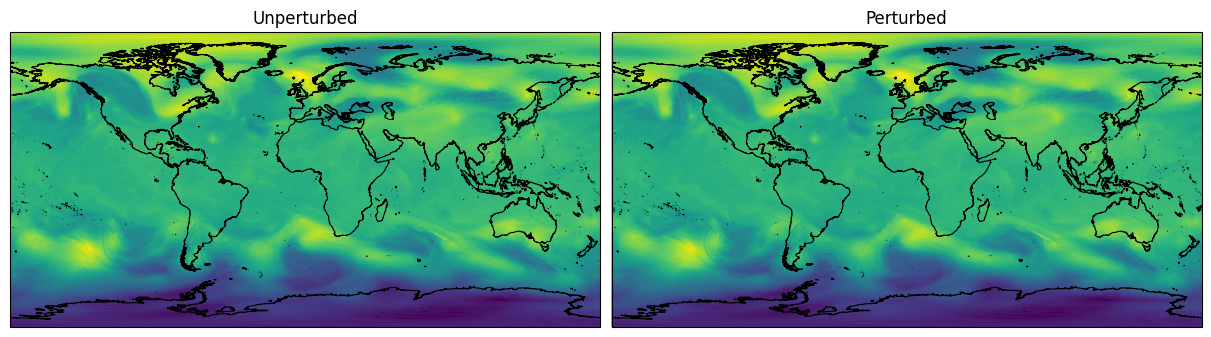

In [49]:
from cartopy import crs as ccrs

var = "temperature"
level = 200

sel = ds_unpert[var] if level is None else ds_unpert[var].sel(level=level)
sel_pert = ds_pert[var] if level is None else ds_pert[var].sel(level=level)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})
axes[0].set_title("Unperturbed")
plot_2d_latlon_dataarray(sel, axes[0])
axes[1].set_title("Perturbed")
plot_2d_latlon_dataarray(sel_pert, axes[1])
plt.show()

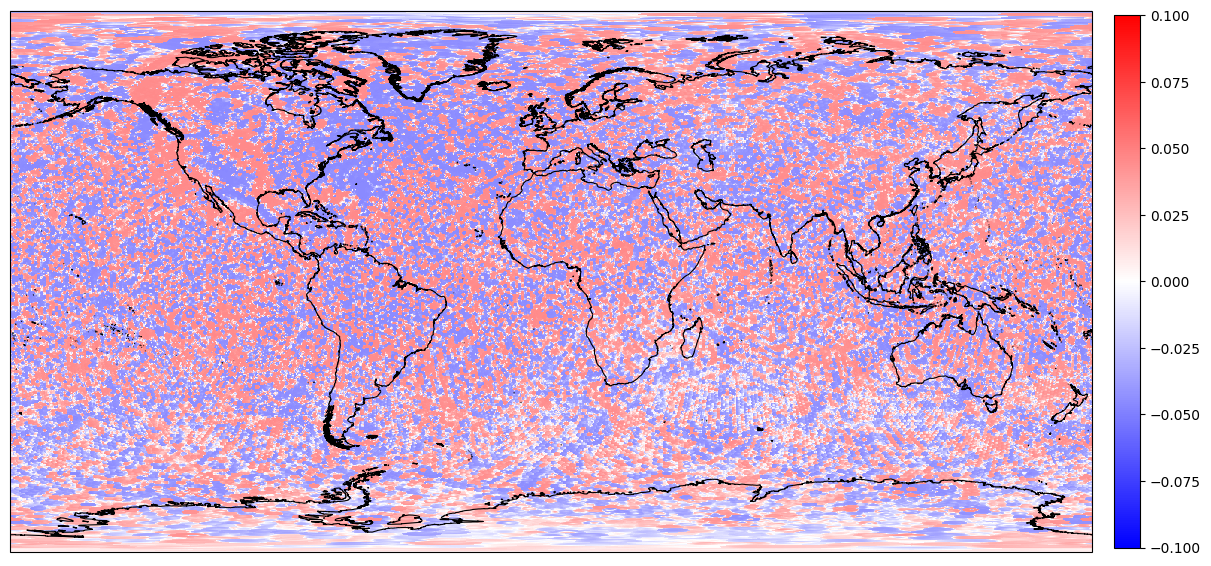

In [51]:
fig, axes = plt.subplots(figsize=(12,6), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})
diff = sel - sel_pert
mesh = plot_2d_latlon_dataarray(diff, axes, vmin=-0.1, vmax=0.1, cmap="bwr")
cbar = fig.colorbar(mesh, ax=np.array(axes).ravel().tolist(), shrink=0.9, pad=0.02)
plt.show()

(array([ 9342., 42873., 45181., 54737., 74859., 94313., 83876., 60719.,
        48939., 44317., 46209., 58479., 77253., 88456., 66937., 50576.,
        42760., 39092.,  9322.]),
 array([-0.03396606, -0.03038908, -0.0268121 , -0.02323512, -0.01965814,
        -0.01608116, -0.01250418, -0.00892719, -0.00535021, -0.00177323,
         0.00180375,  0.00538073,  0.00895771,  0.01253469,  0.01611168,
         0.01968865,  0.02326564,  0.02684262,  0.0304196 ,  0.03399658]),
 <BarContainer object of 19 artists>)

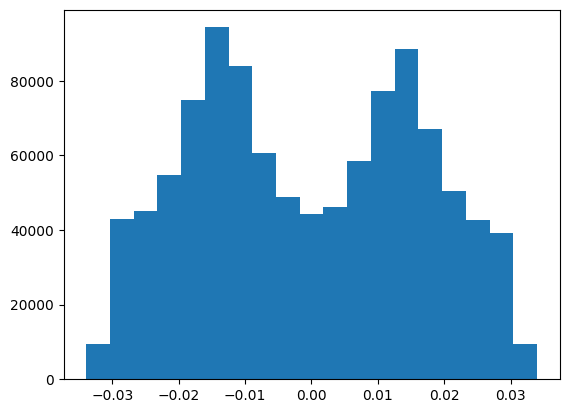

In [40]:
flat = diff.values.flatten()
bins = np.linspace(flat.min(), flat.max(), 20)
plt.hist(flat, bins=bins)

# Softmax visualiation

In [3]:
import xarray 
import numpy as np

def argmin(field: xarray.DataArray) -> tuple[float, float]:
    stacked = field.stack(spatial=("latitude", "longitude"))
    idx = int(stacked.argmin(dim="spatial").values)
    pt = stacked.isel(spatial=idx)
    center_lat = float(pt.latitude.values)
    center_lon = float(pt.longitude.values)
    return (center_lat, center_lon)

output_name = "output_epoch-33.nc"
path = "/home/users/f/froelicm/scratch/output/ian_8step_softmin/lat+24.00_lon+275.00/"

center_lookup = {"latitude": slice(22, 32), "longitude": slice(-88+360, -80+360)}
ds_pert = xarray.open_dataset(f"{path}{output_name}", chunks="auto")["mean_sea_level_pressure"].isel(time=-1).squeeze()
ds_pert = ds_pert.rename({"lat": "latitude", "lon": "longitude"})
loc = argmin(ds_pert.sel(center_lookup))
print(loc)

output_name_unpert = "output_epoch-0.nc"
step = 5
output_lookup = {"latitude": slice(loc[0]-step, loc[0]+step), "longitude": slice(loc[1]-step, loc[1]+step)}
ds_unpert = xarray.open_dataset(f"{path}{output_name_unpert}", chunks="auto")["mean_sea_level_pressure"].isel(time=-1).squeeze()
ds_unpert = ds_unpert.rename({"lat": "latitude", "lon": "longitude"}).sel(output_lookup)

/home/users/f/froelicm/WeatherPlots/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(24.0, 275.0)


In [4]:
def softmax_weights(field: xarray.DataArray, beta: float = -5.0) -> xarray.DataArray:
    assert beta != 0
    if beta < 0: 
        l = field.min(dim=["latitude", "longitude"])
    else:
        l = field.max(dim=["latitude", "longitude"])
    field_exp = np.exp(
        beta * (field - l)
    )
    return field_exp / field_exp.sum(dim=["latitude", "longitude"]) #type: ignore

def gcd(field: xarray.DataArray, target: tuple[float,float]) -> xarray.DataArray:
    R_EARTH_KM = 6371.0

    lat = np.deg2rad(field["latitude"])
    lon = np.deg2rad(field["longitude"])

    clat = np.deg2rad(target[0])
    clon = np.deg2rad(target[1])

    dlat = lat - clat
    dlon = lon - clon

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat) * np.cos(clat) * np.sin(dlon / 2.0) ** 2

    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    return xarray.DataArray(
        R_EARTH_KM * c,
        dims=("latitude", "longitude"),
        coords={
            "latitude": field["latitude"],
            "longitude": field["longitude"],
        },
        name="great_circle_distance",
    )


In [5]:
def normalize(array: xarray.Dataset) -> xarray.Dataset:
  import os 
  home = os.path.expanduser("~")
  stats_path = os.path.join(home, "scratch/GoogleDM/graphcast/stats")
  locations = xarray.load_dataset(
            os.path.join(stats_path, "mean_by_level.nc")
        ).compute()
  scales = xarray.load_dataset(
            os.path.join(stats_path, "stddev_by_level.nc")
        ).compute()
  def normalize_array(array):
      if array.name is None:
        raise ValueError(
            "Can't look up normalization constants because array has no name.")
      if locations is not None:
        if array.name in locations:
          array = array - locations[array.name].astype(array.dtype)
      if array.name in scales:
        array = array / scales[array.name].astype(array.dtype)
      return array
  return normalize_array(array)

ds_unpert_norm = normalize(ds_unpert)
ds_pert_norm = normalize(ds_pert)

In [4]:
softmax_weights_1 = softmax_weights(ds_unpert, beta=-1e-3).compute()
softmax_weights_5 = softmax_weights(ds_unpert, beta=-5e-3).compute()
softmax_weights_10 = softmax_weights(ds_unpert, beta=-1e-2).compute()

ds_gcd = gcd(ds_unpert, loc)

final_spatial_loss = softmax_weights_1 * ds_gcd

In [8]:
softmax_weights_1 = softmax_weights(ds_unpert_norm, beta=-1).compute()
softmax_weights_5 = softmax_weights(ds_unpert_norm, beta=-5).compute()
softmax_weights_10 = softmax_weights(ds_unpert_norm, beta=-10).compute()

ds_gcd = gcd(ds_unpert_norm, loc)

final_spatial_loss = softmax_weights_1 * ds_gcd

In [29]:
def neff(weights: xarray.DataArray) -> float:
    return 1 / (weights**2).sum(("latitude", "longitude")).compute().item()

def beta(ds: xarray.DataArray, target_spread: float) -> float:
    spread = (ds.max(dim=["latitude", "longitude"]) - ds.min(dim=["latitude", "longitude"])).compute().item()
    return -target_spread / spread

In [32]:
spread = (ds_unpert_norm.max(dim=["latitude", "longitude"]) - ds_unpert_norm.min(dim=["latitude", "longitude"])).compute().item()
target_spreads = [4, 8, 12]
softmax_weights_1 = softmax_weights(ds_unpert_norm, beta=-target_spreads[0]/spread).compute()
softmax_weights_5 = softmax_weights(ds_unpert_norm, beta=-target_spreads[1]/spread).compute()
softmax_weights_10 = softmax_weights(ds_unpert_norm, beta=-target_spreads[2]/spread).compute()

ds_gcd = gcd(ds_unpert_norm, loc)

final_spatial_loss = softmax_weights_1 * ds_gcd

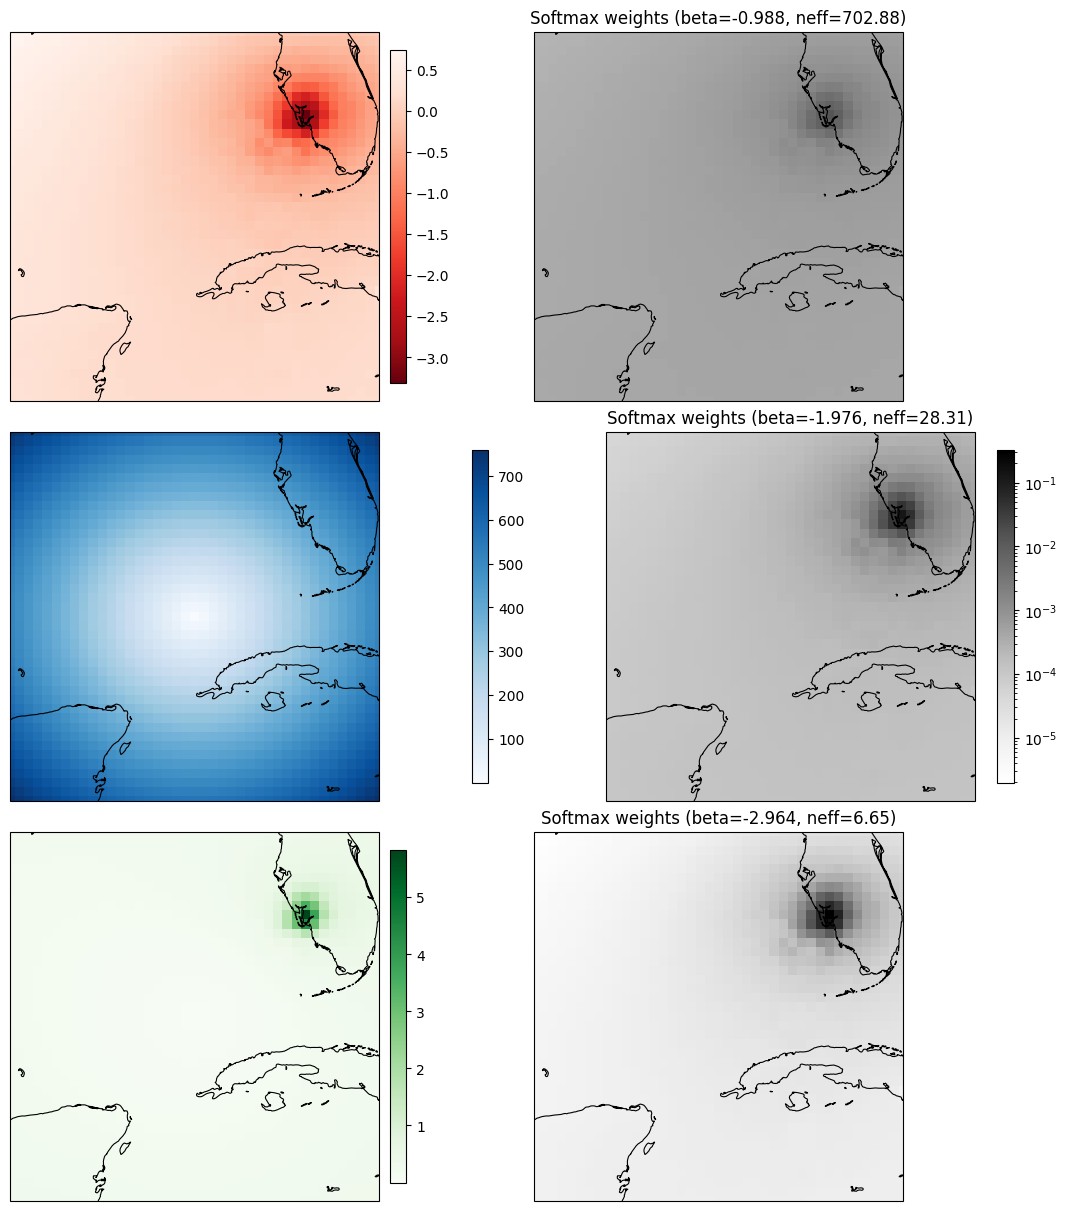

In [33]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs

fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True, subplot_kw={'projection': ccrs.PlateCarree()})

mesh = plot_2d_latlon_dataarray(ds_unpert_norm, axes[0,0], cmap="Reds_r")
cbar_mesh = fig.colorbar(mesh, ax=np.array(axes[0,0]).ravel().tolist(), shrink=0.9, pad=0.02)

mesh_gcd = plot_2d_latlon_dataarray(ds_gcd, axes[1,0], cmap="Blues")
cbar_gcd = fig.colorbar(mesh_gcd, ax=np.array(axes[1,0]).ravel().tolist(), shrink=0.9, pad=0.02)

mesh_loss = plot_2d_latlon_dataarray(final_spatial_loss, axes[2,0], cmap="Greens")
cbar_loss = fig.colorbar(mesh_loss, ax=np.array(axes[2,0]).ravel().tolist(), shrink=0.9, pad=0.02)

norm = LogNorm(vmin=min([softmax_weights_1.min().item(), softmax_weights_5.min().item(), softmax_weights_10.min().item()]), 
        vmax=max([softmax_weights_1.max().item(), softmax_weights_5.max().item(), softmax_weights_10.max().item()]))
mesh1 = plot_2d_latlon_dataarray(softmax_weights_1, axes[0,1], cmap="Greys", norm=norm)
axes[0,1].set_title(f"Softmax weights (beta={-target_spreads[0]/spread:.3f}, neff={1/(softmax_weights_1**2).sum(('latitude', 'longitude')).compute().item():.2f})")
mesh5 = plot_2d_latlon_dataarray(softmax_weights_5, axes[1,1], cmap="Greys", norm=norm)
axes[1,1].set_title(f"Softmax weights (beta={-target_spreads[1]/spread:.3f}, neff={1/(softmax_weights_5**2).sum(('latitude', 'longitude')).compute().item():.2f})")
mesh10 = plot_2d_latlon_dataarray(softmax_weights_10, axes[2,1], cmap="Greys", norm=norm)
axes[2,1].set_title(f"Softmax weights (beta={-target_spreads[2]/spread:.3f}, neff={1/(softmax_weights_10**2).sum(('latitude', 'longitude')).compute().item():.2f})")
cbar = fig.colorbar(mesh1, ax=np.array(axes[1,:]).ravel().tolist(), shrink=0.9, pad=0.02)

plt.show()

In [21]:
spread = (ds_unpert_norm.max(dim=["latitude", "longitude"]) - ds_unpert_norm.min(dim=["latitude", "longitude"])).compute().item()
print(f"Field spread: {spread}")

Field spread: 4.049038887023926


In [24]:
for w in [softmax_weights_1, softmax_weights_5, softmax_weights_10]:
    neff = 1 / (w**2).sum(("latitude", "longitude")).compute().item()
    print(f"Effective no. grid cells: {neff}")

Effective no. grid cells: 1653.9751046931854
Effective no. grid cells: 315.74714658343913
Effective no. grid cells: 11.23547705042556
